<a href="https://colab.research.google.com/github/BharathReddyRamasani/AI_DS/blob/main/cnn_road_damage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'road-damage-dataset-potholes-cracks-and-manholes' dataset.
Path to dataset files: /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes


In [2]:
import os

# List the contents of the downloaded directory to find data files
print(f"Contents of {path}:\n{os.listdir(path)}")

# Assuming 'data' is a subdirectory, list its contents as well
data_subdir_path = os.path.join(path, 'data')
print(f"Contents of {data_subdir_path}:\n{os.listdir(data_subdir_path)}")

Contents of /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes:
['data']
Contents of /kaggle/input/road-damage-dataset-potholes-cracks-and-manholes/data:
['COCO-conversion-script.py', 'labels', 'annotations_coco.json', 'README.md', 'YOLO-conversion-script.py', 'images', 'labels-YOLO']


In [3]:
import pandas as pd
import os
import json

# Construct the path to the annotations_coco.json file
annotations_file_name = 'annotations_coco.json'
data_directory = os.path.join(path, 'data')
annotations_full_path = os.path.join(data_directory, annotations_file_name)

# Load the JSON file
try:
    with open(annotations_full_path, 'r') as f:
        coco_data = json.load(f)
    print(f"Successfully loaded {annotations_file_name}.")

    # Display top-level keys to understand the structure
    print("\nTop-level keys in the COCO JSON file:", coco_data.keys())

    # Try to extract and display 'images' and 'annotations' as DataFrames
    if 'images' in coco_data:
        df_images = pd.DataFrame(coco_data['images'])
        print("\nFirst 5 records of 'images' data:")
        display(df_images.head())
    else:
        print("\n'images' key not found in COCO JSON.")

    if 'annotations' in coco_data:
        df_annotations = pd.DataFrame(coco_data['annotations'])
        print("\nFirst 5 records of 'annotations' data:")
        display(df_annotations.head())
    else:
        print("\n'annotations' key not found in COCO JSON.")

except FileNotFoundError:
    print(f"Error: {annotations_file_name} not found at {annotations_full_path}")
except Exception as e:
    print(f"An error occurred while loading or processing the JSON file: {e}")

Successfully loaded annotations_coco.json.

Top-level keys in the COCO JSON file: dict_keys(['images', 'annotations', 'categories'])

First 5 records of 'images' data:


,id,file_name,width,height
0,1,20250216_164325.jpg,640,360
1,2,20250216_164521.jpg,640,360
2,3,20250216_164541.jpg,640,360
3,4,20250219_164649.jpg,640,360
4,5,20250219_164714.jpg,640,360



First 5 records of 'annotations' data:


,id,image_id,category_id,bbox,area,iscrowd
0,1,1,2,"[203.00032000000002, 173.00016, 190.9996799999...",9931.95280,0
1,2,1,0,"[372.99968, 180.0, 28.000639999999976, 41.0000...",1148.02736,0
2,3,1,0,"[166.0, 186.00011999999998, 32.99968000000001,...",659.98700,0
3,4,1,0,"[231.00032, 171.0, 33.999360000000024, 16.9999...",577.98640,0
4,5,1,1,"[254.0, 226.00007999999997, 32.0, 32.000040000...",1024.00128,0


In [4]:
# Save df_images to a CSV file
images_csv_path = '/content/images.csv'
df_images.to_csv(images_csv_path, index=False)
print(f"'images' data saved to {images_csv_path}")

# Save df_annotations to a CSV file
annotations_csv_path = '/content/annotations.csv'
df_annotations.to_csv(annotations_csv_path, index=False)
print(f"'annotations' data saved to {annotations_csv_path}")

'images' data saved to /content/images.csv
'annotations' data saved to /content/annotations.csv


In [5]:
print("df_images head:")
display(df_images.head())

print("\ndf_annotations head:")
display(df_annotations.head())

df_images head:


,id,file_name,width,height
0,1,20250216_164325.jpg,640,360
1,2,20250216_164521.jpg,640,360
2,3,20250216_164541.jpg,640,360
3,4,20250219_164649.jpg,640,360
4,5,20250219_164714.jpg,640,360



df_annotations head:


,id,image_id,category_id,bbox,area,iscrowd
0,1,1,2,"[203.00032000000002, 173.00016, 190.9996799999...",9931.95280,0
1,2,1,0,"[372.99968, 180.0, 28.000639999999976, 41.0000...",1148.02736,0
2,3,1,0,"[166.0, 186.00011999999998, 32.99968000000001,...",659.98700,0
3,4,1,0,"[231.00032, 171.0, 33.999360000000024, 16.9999...",577.98640,0
4,5,1,1,"[254.0, 226.00007999999997, 32.0, 32.000040000...",1024.00128,0


Data Set Link:
https://www.kaggle.com/datasets/lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes
Problem Statement
A smart city management department wants to automate road monitoring using Artificial Intelligence.
Currently:
road inspections are performed manually
damaged roads are identified late
accidents increase due to potholes and cracks
The department wants an AI-powered system that can:
analyze road images
detect road damage categories
help authorities prioritize maintenance
You are hired as an AI Engineer to build and deploy a CNN-based Road Damage Detection System.
Objective
Build a Convolutional Neural Network (CNN) model that classifies road conditions into different categories using road surface images.
CNN Task Requirements
Task 1 — Dataset Understanding
Analyze the dataset and identify:
number of classes
image dimensions
class imbalance
sample images
Task 2 — Data Preprocessing
Perform:
image resizing
normalization
train/test split
label encoding
Task 3 — Data Augmentation
Apply:
rotation
zoom
horizontal flip
brightness adjustment
Explain:
Why augmentation is important in CNN.
Task 4 — CNN Architecture Design
Students must design a custom CNN architecture using:
Convolution layers
MaxPooling layers
Dropout
Dense layers
Task 5 — Model Training
Train the CNN model using TensorFlow/Keras.
Requirements:
GPU runtime
proper batch size
multiple epochs
validation split
Task 6 — Model Evaluation
Evaluate using:
Accuracy
Precision
Recall
F1 Score
Confusion Matrix
Task 7 — Error Analysis
Students must identify:
wrongly predicted images
possible reasons for failure
class confusion
Task 8 — Real-Time Prediction
Test the model on:
unseen road images
manually uploaded images
Task 9 — Save the CNN Model
Export:
trained model
weights
label mappings
Road Damage Dataset: Potholes, Cracks and Manholes | Kaggle
A curated set of 2,000+ YOLO-annotated road surface images
 **bold text**

## Task 1: Dataset Understanding

In [6]:
import pandas as pd

# Extract categories from coco_data
df_categories = pd.DataFrame(coco_data['categories'])

# Identify number of classes
num_classes = len(df_categories)

print(f"Number of Classes: {num_classes}")
print("\nCategory Details:")
display(df_categories)

Number of Classes: 3

Category Details:


,id,name
0,0,pothole
1,1,crack
2,2,manhole


Next, let's look at the image dimensions from `df_images`.

In [7]:
print("Image Dimensions (width and height):")
display(df_images[['width', 'height']].describe())

Image Dimensions (width and height):


,width,height
count,2009.0,2009.0
mean,640.0,360.0
std,0.0,0.0
min,640.0,360.0
25%,640.0,360.0
50%,640.0,360.0
75%,640.0,360.0
max,640.0,360.0


Now, let's analyze class imbalance by counting the occurrences of each `category_id` in `df_annotations` and mapping them to their names.

Class Distribution:


,count
name,
crack,2519
pothole,1261
manhole,957


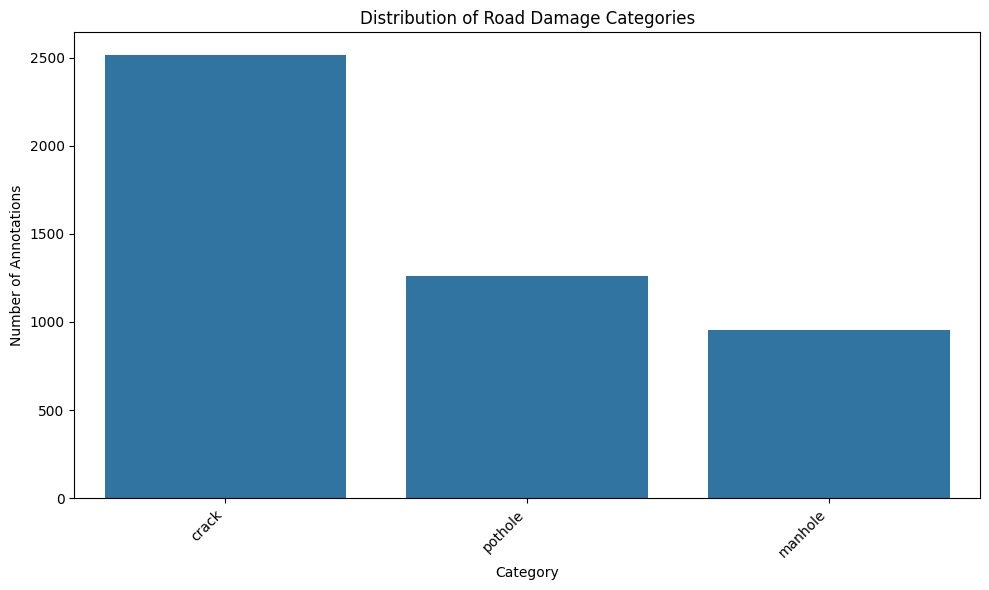

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Merge annotations with categories to get category names
df_annotations_merged = pd.merge(df_annotations, df_categories, left_on='category_id', right_on='id', suffixes=('_annotation', '_category'))

# Count occurrences of each category
class_counts = df_annotations_merged['name'].value_counts()

print("Class Distribution:")
display(class_counts)

# Visualize class distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Distribution of Road Damage Categories')
plt.xlabel('Category')
plt.ylabel('Number of Annotations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Finally, let's display some sample images with their annotations to get a visual understanding of the dataset.

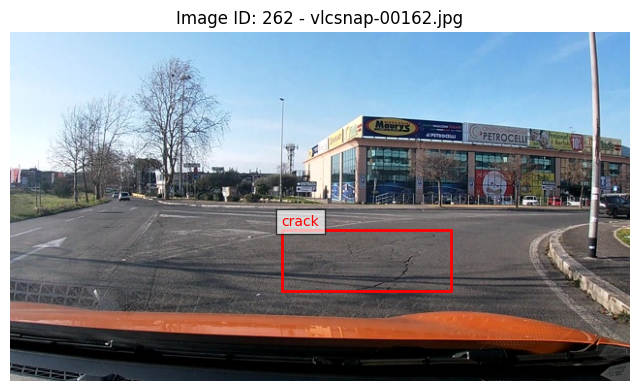

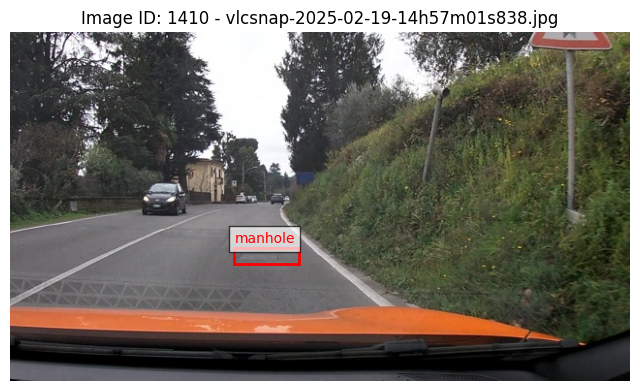

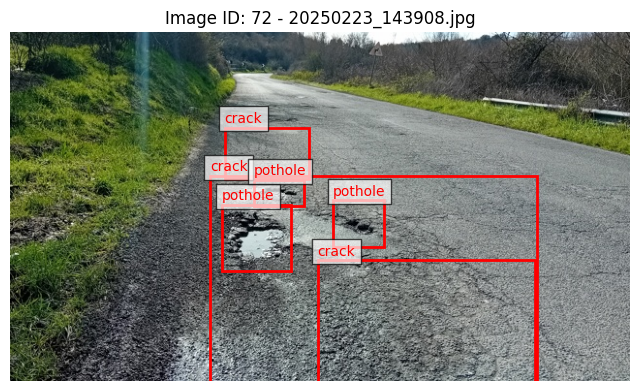

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Function to display image with bounding boxes
def display_image_with_annotations(image_id, num_samples=3):
    img_info = df_images[df_images['id'] == image_id].iloc[0]
    file_name = img_info['file_name']
    image_path = os.path.join(path, 'data', 'images', file_name)

    try:
        img = Image.open(image_path).convert('RGB')
        plt.figure(figsize=(8, 8))
        plt.imshow(img)
        plt.title(f"Image ID: {image_id} - {file_name}")


        img_annotations = df_annotations_merged[df_annotations_merged['image_id'] == image_id]

        for _, ann in img_annotations.iterrows():
            bbox = ann['bbox']

            x, y, w, h = bbox[0], bbox[1], bbox[2], bbox[3]
            category_name = ann['name']

            rect = plt.Rectangle((x, y), w, h, fill=False, edgecolor='red', linewidth=2)
            plt.gca().add_patch(rect)
            plt.text(x, y - 5, category_name, color='red', fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
        plt.axis('off')
        plt.show()
    except FileNotFoundError:
        print(f"Image not found: {image_path}")
    except Exception as e:
        print(f"Error displaying image {file_name}: {e}")

# Display a few sample images
sample_image_ids = df_images['id'].sample(3).tolist() # Get 3 random image IDs
for img_id in sample_image_ids:
    display_image_with_annotations(img_id)

## Task 2: Data Preprocessing

In [10]:
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Define target image dimensions
IMG_WIDTH = 224
IMG_HEIGHT = 224

# Prepare image data and labels
images = []
labels = []

# Create a mapping from image_id to category_id for images with annotations
image_to_category = {}
for _, row in df_annotations.iterrows():

    if row['image_id'] not in image_to_category:
        image_to_category[row['image_id']] = row['category_id']

# Filter df_images to include only images that have annotations and thus a category
df_images_annotated = df_images[df_images['id'].isin(image_to_category.keys())]

print(f"Processing {len(df_images_annotated)} annotated images...")

for idx, row in df_images_annotated.iterrows():
    image_id = row['id']
    file_name = row['file_name']
    image_path = os.path.join(path, 'data', 'images', file_name)

    try:
        # Load image using OpenCV
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB

        # Resize image
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))

        # Normalize pixel values to [0, 1]
        img = img / 255.0

        images.append(img)
        labels.append(image_to_category[image_id])

    except Exception as e:
        print(f"Error processing image {file_name}: {e}")

images = np.array(images)
labels = np.array(labels)

print(f"Loaded {len(images)} images and {len(labels)} labels.")
print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

# Perform train/test split
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)

# One-hot encode labels (label encoding is inherent with category_id, but one-hot is for model input)
y_train_encoded = to_categorical(y_train, num_classes=num_classes)
y_test_encoded = to_categorical(y_test, num_classes=num_classes)

print("\nData Preprocessing Complete:")
print(f"X_train shape: {X_train.shape}, y_train_encoded shape: {y_train_encoded.shape}")
print(f"X_test shape: {X_test.shape}, y_test_encoded shape: {y_test_encoded.shape}")

Processing 2009 annotated images...
Loaded 2009 images and 2009 labels.
Images shape: (2009, 224, 224, 3)
Labels shape: (2009,)

Data Preprocessing Complete:
X_train shape: (1607, 224, 224, 3), y_train_encoded shape: (1607, 3)
X_test shape: (402, 224, 224, 3), y_test_encoded shape: (402, 3)


## Task 3: Data Augmentation

### Why Data Augmentation is Important in CNNs

Data augmentation is a technique used to artificially increase the size of a training dataset by creating modified versions of existing images. This is particularly important for Convolutional Neural Networks (CNNs) for several reasons:

1.  **Combating Overfitting**: CNNs are powerful models with many parameters. If the training dataset is small, the model can memorize the training examples rather than learning generalizable features, leading to poor performance on unseen data (overfitting). Augmentation provides more diverse training data, making the model more robust.

2.  **Improving Generalization**: By presenting the model with variations of the same image (e.g., rotated, zoomed, flipped), the CNN learns to recognize the core features of an object regardless of its orientation, size, or lighting conditions. This helps the model generalize better to real-world scenarios where image conditions can vary widely.

3.  **Increasing Dataset Size**: In many practical applications, acquiring a large, diverse dataset is expensive and time-consuming. Data augmentation offers a cost-effective way to expand the dataset, which is crucial for training deep learning models effectively.

4.  **Enhancing Robustness**: Augmentation introduces noise and variations that mimic real-world imperfections (e.g., different angles, partial obscuration), making the model more resilient to such variations during inference.

Common augmentation techniques include:
*   **Rotation**: Rotating images by a certain degree.
*   **Zoom**: Zooming in or out of images.
*   **Horizontal/Vertical Flip**: Flipping images along their horizontal or vertical axis.
*   **Brightness Adjustment**: Changing the brightness of images.
*   **Shift**: Shifting images horizontally or vertically.

These transformations help the model learn more invariant features, ultimately leading to better performance and reliability.

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define data augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=20,          # Rotate images by up to 20 degrees
    zoom_range=0.2,             # Zoom in/out by up to 20%
    horizontal_flip=True,       # Randomly flip images horizontally
    brightness_range=[0.8, 1.2] # Adjust brightness by 20% (darker/brighter)
)

# Fit the data augmentation generator on the training data
# This step is optional if you just want to generate augmented images on the fly during training
# However, it's good practice to fit it once if you are going to use flow() or flow_from_directory()
datagen.fit(X_train)

print("ImageDataGenerator configured and fitted to X_train.")

ImageDataGenerator configured and fitted to X_train.


## Task 4: CNN Architecture Design

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the CNN model architecture
model = Sequential([
    # First Convolutional Block
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Second Convolutional Block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Third Convolutional Block
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Flattening for Dense layers
    Flatten(),

    # Dense Layers
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') # Output layer with num_classes and softmax activation
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("CNN Model Architecture Defined and Compiled.")
# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Model Architecture Defined and Compiled.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,397,635 (169.36 MB)

 Trainable params: 44,397,635 (169.36 MB)

 Non-trainable params: 0 (0.00 B)

## Task 5: Model Training

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

# Define training parameters
BATCH_SIZE = 32
EPOCHS = 10 # You might want to increase this for better performance, but 50 is a good starting point

# Implement Early Stopping to prevent overfitting and save training time
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=10,         # Stop if validation loss doesn't improve for 10 epochs
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

print(f"Training the model for {EPOCHS} epochs with a batch size of {BATCH_SIZE}...")

# Train the model using the ImageDataGenerator for augmentation
history = model.fit(
    datagen.flow(X_train, y_train_encoded, batch_size=BATCH_SIZE), # Use augmented data for training
    epochs=EPOCHS,
    validation_data=(X_test, y_test_encoded),
    callbacks=[early_stopping]
)

print("Model training complete.")

Training the model for 10 epochs with a batch size of 32...
Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 42s 612ms/step - accuracy: 0.4922 - loss: 1.0709 - val_accuracy: 0.5000 - val_loss: 1.0808
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 25s 501ms/step - accuracy: 0.4972 - loss: 1.0411 - val_accuracy: 0.5000 - val_loss: 1.0735
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 22s 441ms/step - accuracy: 0.4966 - loss: 1.0375 - val_accuracy: 0.5000 - val_loss: 1.0391
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 20s 401ms/step - accuracy: 0.5034 - loss: 1.0375 - val_accuracy: 0.4303 - val_loss: 1.2165
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 438ms/step - accuracy: 0.4966 - loss: 1.0428 - val_accuracy: 0.5000 - val_loss: 1.0665
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 448ms/step - accuracy: 0.5009 - loss: 1.0336 - val_accuracy: 0.2687 - val_loss: 1.2398
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 22s 434ms/step - accuracy: 0.4984 - loss: 1.0385 - val_accuracy: 0.2985 - val_loss: 1.0941
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━

## Task 6: Model Evaluation

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step

--- Model Evaluation Results ---

Classification Report:
              precision    recall  f1-score   support

     pothole       0.00      0.00      0.00        93
       crack       0.50      1.00      0.67       201
     manhole       0.00      0.00      0.00       108

    accuracy                           0.50       402
   macro avg       0.17      0.33      0.22       402
weighted avg       0.25      0.50      0.33       402



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


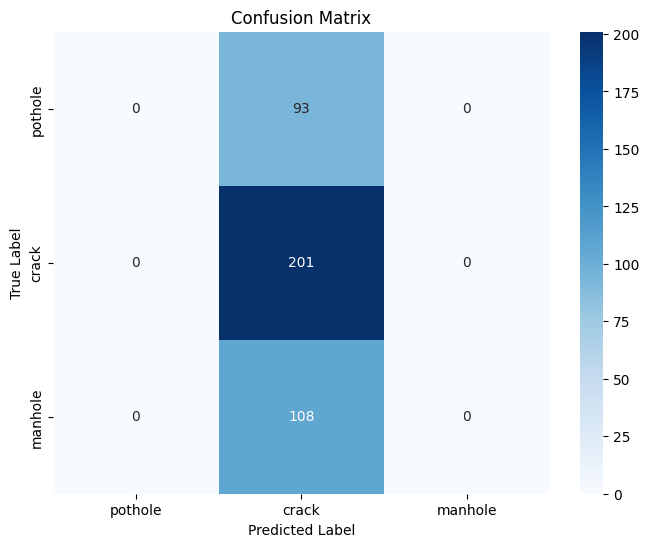


Overall Test Accuracy: 0.5000
Overall Test Loss: 1.0391


In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred_encoded = model.predict(X_test)
y_pred = np.argmax(y_pred_encoded, axis=1)
y_true = np.argmax(y_test_encoded, axis=1)

# Get class names from df_categories for better readability
class_names = df_categories['name'].tolist()

print("\n--- Model Evaluation Results ---")

# 1. Accuracy, Precision, Recall, F1-Score
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 2. Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Display overall accuracy
loss, accuracy = model.evaluate(X_test, y_test_encoded, verbose=0)
print(f"\nOverall Test Accuracy: {accuracy:.4f}")
print(f"Overall Test Loss: {loss:.4f}")

## Task 7: Error Analysis

Total misclassified images: 201

--- Sample of Misclassified Images ---


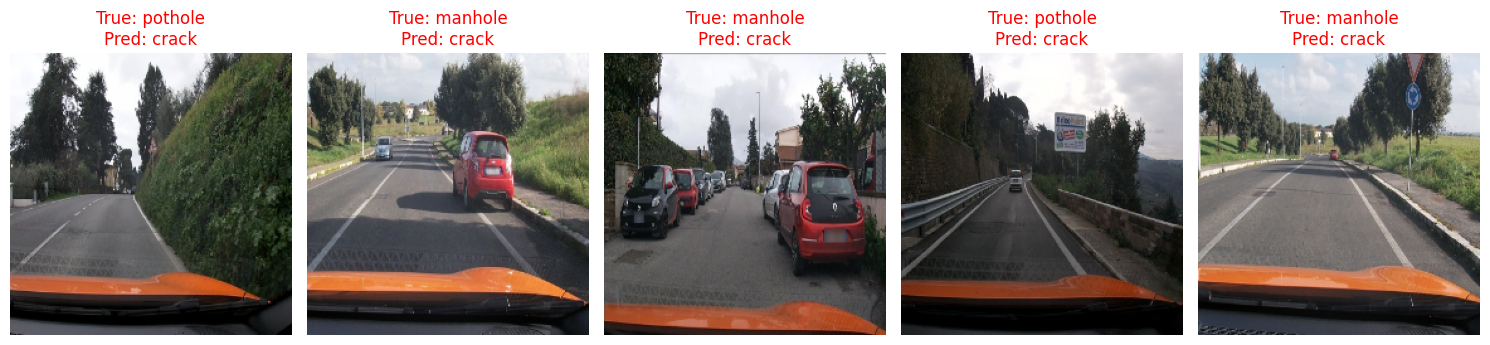


--- Class Confusion Matrix ---


,pothole,crack,manhole
pothole,0,93,0
crack,0,201,0
manhole,0,108,0



Possible reasons for failure and class confusion based on the confusion matrix and sample images:
- **Visual Similarity**: Some damage types (e.g., small cracks and potholes) might have similar visual features, making them hard to distinguish.
- **Imbalanced Dataset**: If certain classes have significantly fewer training examples, the model might struggle to learn their features effectively.
- **Annotation Quality**: Inconsistent or imprecise annotations can introduce noise into the training process.
- **Image Quality**: Blurry images, poor lighting conditions, or occlusions can hinder accurate classification.
- **Model Complexity**: The current CNN architecture might not be complex enough to capture subtle differences between classes, or it might be too complex and overfitting.
- **Limited Data Augmentation**: While augmentation was applied, it might not be sufficient or diverse enough to cover all real-world variations.


In [15]:
import random

# Identify wrongly predicted images
misclassified_indices = np.where(y_pred != y_true)[0]
print(f"Total misclassified images: {len(misclassified_indices)}")

# Function to display misclassified images with true and predicted labels
def display_misclassified_images(indices, X_data, y_true_labels, y_pred_labels, class_names, num_images=5):
    if len(indices) == 0:
        print("No misclassified images to display.")
        return

    # Randomly sample some misclassified images if there are many
    sample_indices = random.sample(list(indices), min(len(indices), num_images))

    plt.figure(figsize=(15, 10))
    for i, idx in enumerate(sample_indices):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(X_data[idx])
        true_label = class_names[y_true_labels[idx]]
        pred_label = class_names[y_pred_labels[idx]]
        plt.title(f"True: {true_label}\nPred: {pred_label}", color='red' if true_label != pred_label else 'black')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("\n--- Sample of Misclassified Images ---")
display_misclassified_images(misclassified_indices, X_test, y_true, y_pred, class_names, num_images=5)


print("\n--- Class Confusion Matrix ---")
display(pd.DataFrame(conf_matrix, index=class_names, columns=class_names))


## Task 8: Real-Time Prediction

Upload an image to get a real-time prediction:


FileUpload(value={}, accept='image/*', description='Upload')


--- Prediction on a random 'unseen' test image (from X_test) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 747ms/step


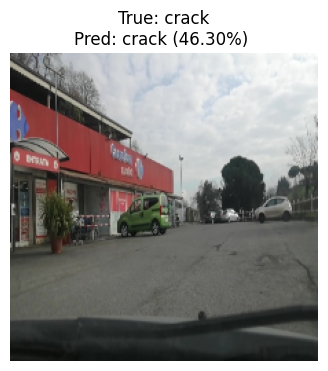

True Label: crack
Predicted Label: crack (Confidence: 46.30%)


In [16]:
import ipywidgets as widgets
from IPython.display import display, Image as IPImage
from io import BytesIO
from PIL import Image
import cv2

# Function to preprocess a single image for prediction
def preprocess_image_for_prediction(image_data):
    # Convert bytes data to PIL Image
    pil_img = Image.open(BytesIO(image_data))
    pil_img = pil_img.convert('RGB') # Ensure RGB format

    # Convert PIL Image to OpenCV format (numpy array)
    img_np = np.array(pil_img)

    # Resize to target dimensions
    img_resized = cv2.resize(img_np, (IMG_WIDTH, IMG_HEIGHT))

    # Normalize pixel values
    img_normalized = img_resized / 255.0

    # Add batch dimension (model expects a batch of images)
    img_preprocessed = np.expand_dims(img_normalized, axis=0)

    return img_preprocessed

# Function to make a prediction and display result
def predict_uploaded_image(change):
    for name, file_info in uploader.value.items():
        image_data = file_info['content']
        img_preprocessed = preprocess_image_for_prediction(image_data)

        # Make prediction
        prediction = model.predict(img_preprocessed)
        predicted_class_index = np.argmax(prediction)
        predicted_class_name = class_names[predicted_class_index]
        confidence = prediction[0][predicted_class_index] * 100

        # Display the uploaded image
        display(IPImage(image_data))
        print(f"Uploaded image: {name}")
        print(f"Predicted Class: {predicted_class_name} (Confidence: {confidence:.2f}%)")
        print("\n---")

# Create a file upload widget
uploader = widgets.FileUpload(
    accept='image/*',  # Accepted file types
    multiple=False     # Allow only one file upload at a time
)

uploader.observe(predict_uploaded_image, names='value')

print("Upload an image to get a real-time prediction:")
display(uploader)


print("\n--- Prediction on a random 'unseen' test image (from X_test) ---")
random_test_idx = np.random.randint(0, len(X_test))
sample_image = X_test[random_test_idx]
sample_true_label = class_names[y_true[random_test_idx]]

# Add batch dimension for prediction
sample_image_batch = np.expand_dims(sample_image, axis=0)
prediction = model.predict(sample_image_batch)
predicted_class_index = np.argmax(prediction)
predicted_class_name = class_names[predicted_class_index]
confidence = prediction[0][predicted_class_index] * 100

plt.figure(figsize=(4, 4))
plt.imshow(sample_image)
plt.title(f"True: {sample_true_label}\nPred: {predicted_class_name} ({confidence:.2f}%) ", color='red' if sample_true_label != predicted_class_name else 'black')
plt.axis('off')
plt.show()

print(f"True Label: {sample_true_label}")
print(f"Predicted Label: {predicted_class_name} (Confidence: {confidence:.2f}%)")

## Task 9: Save the CNN Model

In [17]:
import os
import json

# Define paths for saving the model and related files
model_save_path = '/content/road_damage_cnn_model.keras' # Keras native format
label_mapping_path = '/content/label_mapping.json'

# Save the model
model.save(model_save_path)
print(f"Model saved to: {model_save_path}")

# Save label mappings (category_id to category_name)
label_mapping = {int(row['id']): row['name'] for _, row in df_categories.iterrows()}
with open(label_mapping_path, 'w') as f:
    json.dump(label_mapping, f, indent=4)
print(f"Label mapping saved to: {label_mapping_path}")

print("\nTo load the model later:")
print("from tensorflow.keras.models import load_model")
print(f"loaded_model = load_model('{model_save_path}')")
print("\nTo load the label mapping:")
print("import json")
print(f"with open('{label_mapping_path}', 'r') as f:\n    loaded_label_mapping = json.load(f)")
print("print(loaded_label_mapping)")

Model saved to: /content/road_damage_cnn_model.keras
Label mapping saved to: /content/label_mapping.json

To load the model later:
from tensorflow.keras.models import load_model
loaded_model = load_model('/content/road_damage_cnn_model.keras')

To load the label mapping:
import json
with open('/content/label_mapping.json', 'r') as f:
    loaded_label_mapping = json.load(f)
print(loaded_label_mapping)


In [18]:
num_classes = len(df_categories)

print("Number of Classes:", num_classes)
print(df_categories)

Number of Classes: 3
   id     name
0   0  pothole
1   1    crack
2   2  manhole
